# **EDA — ViClickbait-2025**



## 1.Cài đặt & Import thư viện

In [1]:
!pip install underthesea pyvi wordcloud matplotlib seaborn plotly scipy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 58.3 MB/s eta 0:00:00


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

try:
    from underthesea import word_tokenize
    UNDERTHESEA_AVAILABLE = True
    print('underthesea loaded')
except ImportError:
    UNDERTHESEA_AVAILABLE = False
    print('underthesea not available, using split() instead')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False
})

CB_COLOR  = '#E74C3C'
NCB_COLOR = '#2ECC71'
NEUTRAL_COLOR = '#5D6D7E'
PALETTE   = {'Clickbait': CB_COLOR, 'Non-clickbait': NCB_COLOR}

print('All libraries imported successfully!')

underthesea loaded
All libraries imported successfully!


## 2.Load dữ liệu

In [3]:
df = pd.read_csv('/content/clickbait_dataset_vietnamese.csv')
print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
display(df.head(3))

Dataset loaded: 3,414 rows x 9 columns


,id,url,title,lead_paragraph,category,publish_datetime,source,thumbnail_url,label
0,article_0001,https://vnexpress.net/san-bay-vinh-dong-cua-6-...,Sân bay Vinh đóng cửa 6 tháng để nâng cấp,Nghệ AnCảng hàng không Vinh sẽ ngừng hoạt động...,Tin tức tổng hợp,2025-06-23T12:26:00+07:00,VnExpress,data/images/article_0001_image.png,non-clickbait
1,article_0002,https://vnexpress.net/5-nguoi-thoat-nan-khi-ot...,5 người thoát nạn khi ôtô bị lũ cuốn,Tuyên QuangĐi theo Google Maps song lại được c...,Tin tức tổng hợp,2025-06-23T12:26:00+07:00,VnExpress,data/images/article_0002_image.png,non-clickbait
2,article_0004,https://vnexpress.net/quy-hoach-9-khu-chuc-nan...,Quy hoạch 9 khu chức năng phía đông TP HCM,9 đồ án quy hoạch 1/2000 được TP Thủ Đức phê d...,Tin tức tổng hợp,2025-06-23T11:56:00+07:00,VnExpress,data/images/article_0004_image.png,non-clickbait


## 3.Tổng quan cấu trúc schema dataset

In [4]:
EXPECTED_COLUMNS = [
    'id', 'url', 'title', 'lead_paragraph', 'category',
    'publish_datetime', 'source', 'thumbnail_url', 'label'
]

schema_check = pd.DataFrame({
    'column': EXPECTED_COLUMNS,
    'exists': [c in df.columns for c in EXPECTED_COLUMNS],
    'dtype': [str(df[c].dtype) if c in df.columns else None for c in EXPECTED_COLUMNS],
    'n_missing': [df[c].isna().sum() if c in df.columns else None for c in EXPECTED_COLUMNS],
})

In [5]:
print('=' * 72)
print(f'  Số mẫu (rows):      {df.shape[0]:>10,}')
print(f'  Số trường (cols):   {df.shape[1]:>10}')
print('=' * 72)
print('\nDanh sách trường và kiểu dữ liệu:')
print(df.dtypes.to_string())

  Số mẫu (rows):           3,414
  Số trường (cols):            9

Danh sách trường và kiểu dữ liệu:
id                  object
url                 object
title               object
lead_paragraph      object
category            object
publish_datetime    object
source              object
thumbnail_url       object
label               object


In [6]:
print('\nSchema check:')
display(schema_check)

missing_expected = [c for c in EXPECTED_COLUMNS if c not in df.columns]
extra_columns = [c for c in df.columns if c not in EXPECTED_COLUMNS]
if missing_expected:
    print(f'CẢNH BÁO: Thiếu cột bắt buộc: {missing_expected}')
if extra_columns:
    print(f'Ghi chú: Có cột ngoài schema dự kiến: {extra_columns}')


Schema check:


,column,exists,dtype,n_missing
0,id,True,object,0
1,url,True,object,0
2,title,True,object,0
3,lead_paragraph,True,object,3
4,category,True,object,0
5,publish_datetime,True,object,31
6,source,True,object,0
7,thumbnail_url,True,object,4
8,label,True,object,0


In [8]:
field_desc = pd.DataFrame({
    'Trường': [
        'id', 'url', 'title', 'lead_paragraph', 'category',
        'publish_datetime', 'source', 'thumbnail_url', 'label'
    ],
    'Nhóm': [
        'Metadata', 'Metadata', 'Text input', 'Text input',
        'Domain metadata', 'Temporal metadata', 'Domain metadata',
        'Multimodal metadata', 'Target label'
    ],
    'Kiểu dữ liệu kỳ vọng': [
        'string', 'string/url', 'string', 'string',
        'categorical', 'datetime/string', 'categorical',
        'string/path', 'binary label'
    ],
    'Vai trò trong Phase 2': [
        'Định danh bản ghi, dùng để trace mẫu khi phân tích lỗi',
        'Dùng để kiểm tra duplicate URL hoặc nguồn bài viết',
        'Đầu vào chính cho headline-only clickbait detection',
        'Ngữ cảnh phụ, dùng cho phân tích title+lead hoặc ablation',
        'Dùng để audit category bias và category-held-out evaluation',
        'Dùng để audit temporal bias và temporal split',
        'Dùng để audit source bias và leave-one-source-out evaluation',
        'Không dùng trong scope hiện tại vì chưa làm multimodal',
        'Nhãn nhị phân: clickbait / non-clickbait'
    ],
    'Dùng làm feature chính?': [
        'Không', 'Không', 'Có', 'Có điều kiện',
        'Không trong benchmark chính', 'Không trong benchmark chính',
        'Không trong benchmark chính', 'Không', 'Target'
    ],
    'Rủi ro nếu dùng sai': [
        'Không đáng kể',
        'Có thể leak source hoặc article identity',
        'Không',
        'Có thể thay đổi bài toán từ headline-only sang title+context',
        'Có thể gây category shortcut',
        'Có thể gây temporal shortcut',
        'Có thể gây source shortcut',
        'Dẫn sang multimodal, ngoài scope hiện tại',
        'Không được dùng làm input'
    ]
})

display(field_desc)

,Trường,Nhóm,Kiểu dữ liệu kỳ vọng,Vai trò trong Phase 2,Dùng làm feature chính?,Rủi ro nếu dùng sai
0,id,Metadata,string,"Định danh bản ghi, dùng để trace mẫu khi phân ...",Không,Không đáng kể
1,url,Metadata,string/url,Dùng để kiểm tra duplicate URL hoặc nguồn bài ...,Không,Có thể leak source hoặc article identity
2,title,Text input,string,Đầu vào chính cho headline-only clickbait dete...,Có,Không
3,lead_paragraph,Text input,string,"Ngữ cảnh phụ, dùng cho phân tích title+lead ho...",Có điều kiện,Có thể thay đổi bài toán từ headline-only sang...
4,category,Domain metadata,categorical,Dùng để audit category bias và category-held-o...,Không trong benchmark chính,Có thể gây category shortcut
5,publish_datetime,Temporal metadata,datetime/string,Dùng để audit temporal bias và temporal split,Không trong benchmark chính,Có thể gây temporal shortcut
6,source,Domain metadata,categorical,Dùng để audit source bias và leave-one-source-...,Không trong benchmark chính,Có thể gây source shortcut
7,thumbnail_url,Multimodal metadata,string/path,Không dùng trong scope hiện tại vì chưa làm mu...,Không,"Dẫn sang multimodal, ngoài scope hiện tại"
8,label,Target label,binary label,Nhãn nhị phân: clickbait / non-clickbait,Target,Không được dùng làm input


In [9]:
print('Thống kê mô tả nhanh cho trường văn bản:')
quick_text_stats = pd.DataFrame({
    'title_len': df['title'].fillna('').str.len(),
    'lead_len': df['lead_paragraph'].fillna('').str.len(),
})
display(quick_text_stats.describe().round(2))

Thống kê mô tả nhanh cho trường văn bản:


,title_len,lead_len
count,3414.00,3414.00
mean,66.64,162.44
std,21.17,60.20
min,4.00,0.00
25%,52.00,124.00
50%,66.00,151.00
75%,79.00,191.00
max,186.00,541.00


## 4.Kiểm tra Missing Values & Duplicates

Missing values theo cột:


,Missing count,Missing (%)
publish_datetime,31,0.91
thumbnail_url,4,0.12
lead_paragraph,3,0.09
id,0,0.00
url,0,0.00
category,0,0.00
title,0,0.00
source,0,0.00
label,0,0.00



Số dòng thiếu cột bắt buộc cho headline-only ['title', 'label']: 0
Số dòng giữ lại được cho headline-only: 3,414/3,414


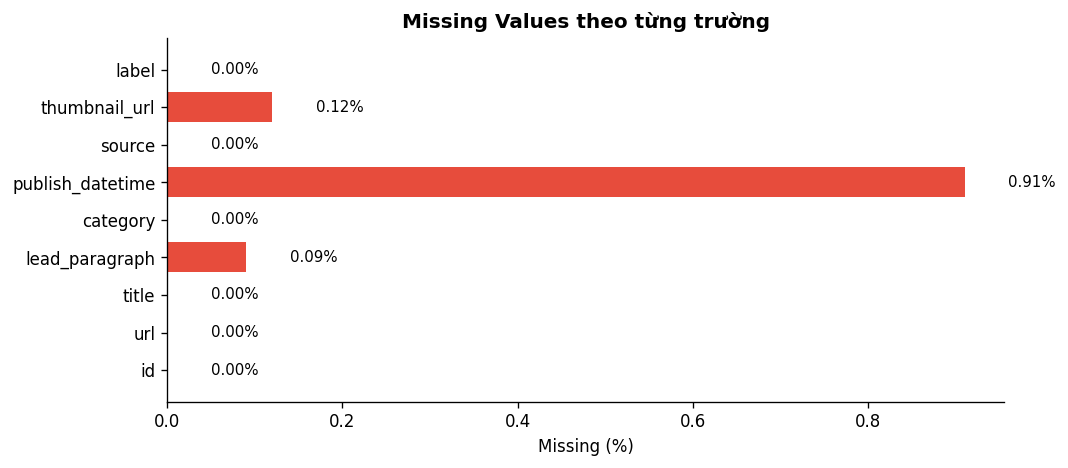

In [10]:
df = df.replace(['', 'None', 'none', 'nan', 'NaN', 'NULL', 'null'], pd.NA)

missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing count': missing, 'Missing (%)': missing_pct})

print('Missing values theo cột:')
display(missing_df.sort_values('Missing (%)', ascending=False))

critical_cols = ['title', 'label']
critical_missing = df[critical_cols].isna().any(axis=1).sum()
print(f'\nSố dòng thiếu cột bắt buộc cho headline-only {critical_cols}: {critical_missing}')
print(f'Số dòng giữ lại được cho headline-only: {len(df) - critical_missing:,}/{len(df):,}')

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#E74C3C' if v > 0 else '#BDC3C7' for v in missing.values]
bars = ax.barh(missing.index, missing_pct.values, color=colors)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values theo từng trường', fontweight='bold')
for bar, val in zip(bars, missing_pct.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [12]:
missing_action = pd.DataFrame({
    'Cột': EXPECTED_COLUMNS,
    'Missing count': [df[c].isna().sum() for c in EXPECTED_COLUMNS],
})

display(missing_action)

rows_before = len(df)
df = df.dropna(subset=['title', 'label']).reset_index(drop=True)
rows_after = len(df)

print(f'Trước xử lý cột bắt buộc: {rows_before:,} dòng')
print(f'Sau xử lý cột bắt buộc:   {rows_after:,} dòng')
print(f'Số dòng bị loại:          {rows_before - rows_after:,}')
print('Ghi chú: Không drop dòng chỉ thiếu lead_paragraph/thumbnail_url/publish_datetime.')

,Cột,Missing count
0,id,0
1,url,0
2,title,0
3,lead_paragraph,3
4,category,0
5,publish_datetime,31
6,source,0
7,thumbnail_url,4
8,label,0


Trước xử lý cột bắt buộc: 3,414 dòng
Sau xử lý cột bắt buộc:   3,414 dòng
Số dòng bị loại:          0
Ghi chú: Không drop dòng chỉ thiếu lead_paragraph/thumbnail_url/publish_datetime.


In [16]:
# =============== DUPLICATE AND NEAR-DUPLICATE AUDIT

# MỤC TIÊU: Phát hiện rủi ro leakage trước khi tạo split.
# Nếu hai title gần giống nhau rơi vào train/test khác nhau, điểm benchmark có thể bị thổi phồng.
def normalize_title(text):
    text = str(text).lower().strip()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(
        r'[^\w\sàáảãạăằắẳẵặâầấẩẫậèéẻẽẹêềếểễệìíỉĩịòóỏõọôồốổỗộơờớởỡợùúủũụưừứửữựỳýỷỹỵđ]',
        '',
        text,
    )
    return text.strip()

exact_dup_all = df.duplicated().sum()
exact_dup_title = df['title'].duplicated().sum()
exact_dup_url = df['url'].duplicated().sum() if 'url' in df.columns else 0

normalized_title = df['title'].fillna('').apply(normalize_title)
normalized_dup_title = normalized_title.duplicated().sum()

print(f'Duplicate toàn bộ dòng:         {exact_dup_all}')
print(f'Duplicate cột title:            {exact_dup_title}')
print(f'Duplicate normalized title:     {normalized_dup_title}')
print(f'Duplicate cột url:              {exact_dup_url}')

if normalized_dup_title > 0:
    print('\nVí dụ normalized title bị trùng:')
    dup_idx = normalized_title[normalized_title.duplicated(keep=False)].index
    display(df.loc[dup_idx, ['id', 'title', 'source', 'category', 'label']].head(10))
else:
    print('\nKhông phát hiện duplicate title sau chuẩn hóa đơn giản.')

Duplicate toàn bộ dòng:         0
Duplicate cột title:            0
Duplicate normalized title:     3
Duplicate cột url:              0

Ví dụ normalized title bị trùng:


,id,title,source,category,label
119,article_0130,Giải thể 44 Bộ chỉ huy Bộ đội Biên phòng các t...,VietNamNet,Chính trị & An ninh,non-clickbait
312,article_0381,Giải thể 44 bộ chỉ huy Bộ đội biên phòng các t...,Thanh Niên,Other,non-clickbait
537,article_0680,Vì sao giá vàng thế giới được dự báo giảm mạnh...,VietNamNet,Kinh doanh & Kinh tế,non-clickbait
2623,article_0695,"Phải đến khi “anh Long” sang Việt Nam, nhiều n...",Kênh14,Giải trí & Showbiz,clickbait
2700,article_1013,Vì sao giá vàng thế giới được dự báo giảm mạnh...,24h,Kinh doanh & Kinh tế,clickbait
3260,article_3168,"Phải đến khi ""anh Long” sang Việt Nam, nhiều n...",24h,Giải trí & Showbiz,clickbait


In [17]:
# Near-duplicate audit bằng char n-gram TF-IDF + nearest neighbor.
# Chỉ dùng để audit leakage trước split, không dùng làm feature cho model.
valid_titles = df['title'].fillna('').astype(str)
near_dup_df = pd.DataFrame()

if len(valid_titles) > 1:
    tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=1)
    X_title = tfidf.fit_transform(valid_titles)
    nn = NearestNeighbors(n_neighbors=2, metric='cosine')
    nn.fit(X_title)
    distances, indices = nn.kneighbors(X_title)

    nearest_similarity = 1 - distances[:, 1]
    nearest_index = indices[:, 1]

    near_dup_df = pd.DataFrame({
        'idx_a': np.arange(len(df)),
        'idx_b': nearest_index,
        'similarity': nearest_similarity,
        'title_a': df['title'].values,
        'title_b': df['title'].iloc[nearest_index].values,
        'label_a': df['label'].values,
        'label_b': df['label'].iloc[nearest_index].values,
    })
    near_dup_df = near_dup_df[near_dup_df['idx_a'] < near_dup_df['idx_b']]
    near_dup_df = near_dup_df[near_dup_df['similarity'] >= 0.92].sort_values('similarity', ascending=False)

print(f'Số cặp near-duplicate title nghi ngờ (similarity >= 0.92): {len(near_dup_df)}')
display(near_dup_df.head(10))

Số cặp near-duplicate title nghi ngờ (similarity >= 0.92): 16


,idx_a,idx_b,similarity,title_a,title_b,label_a,label_b
169,169,1572,0.952295,Dùng camera gắn cúc áo để gian lận thi sát hạc...,Dùng camera cúc áo để gian lận thi sát hạch lá...,non-clickbait,non-clickbait
184,184,438,0.950179,Tòa án Hiến pháp Thái Lan xem xét kiến nghị đì...,Tòa án Hiến pháp Thái Lan xem xét kiến nghị đì...,non-clickbait,non-clickbait
106,106,159,0.946971,Đại sứ quán Việt Nam tại Israel ra thông báo k...,Sứ quán Việt Nam tại Israel ra thông báo khẩn ...,non-clickbait,non-clickbait
537,537,2700,0.944688,Vì sao giá vàng thế giới được dự báo giảm mạnh...,Vì sao giá vàng thế giới được dự báo giảm mạnh...,non-clickbait,clickbait
101,101,2081,0.942963,Bộ Quốc phòng công khai quy hoạch chi tiết mở ...,Bộ Quốc phòng công bố chi tiết quy hoạch mở rộ...,non-clickbait,non-clickbait
68,68,1646,0.938981,Kế hoạch hành động chiến lược triển khai Nghị ...,Kế hoạch hành động triển khai Nghị quyết 57: T...,non-clickbait,non-clickbait
1451,1451,1620,0.938683,Ngày hội văn hóa áo dài TP.HCM,Ngày hội văn hóa áo dài TP.HCM 2025,non-clickbait,non-clickbait
1692,1692,2457,0.935802,Công an Hà Nội khởi tố Tiktoker Vũ Hồng Phúc '...,Công an Hà Nội khởi tố Tiktoker Vũ Hồng Phúc '...,non-clickbait,non-clickbait
219,219,763,0.935482,"Lautaro Martinez ghi tuyệt phẩm, Inter Milan t...","Lautaro Martinez ghi tuyệt phẩm, Inter Milan t...",non-clickbait,non-clickbait
1531,1531,1913,0.932905,Redmi K90 Pro sẽ có camera tele tiềm vọng chất...,Redmi K90 Pro sẽ có camera tele tiềm vọng chất...,non-clickbait,non-clickbait


## 5.Phân tích biến Label (Target)

In [18]:
label_raw = df['label'].copy()
label_norm = label_raw.astype(str).str.strip().str.lower()

label_map = {
    'clickbait': 1,
    'non-clickbait': 0,
    'non clickbait': 0,
    '0': 0,
    '1': 1,
}

df['label'] = label_norm.map(label_map)
if df['label'].isna().any():
    bad_labels = label_raw[df['label'].isna()].unique()
    raise ValueError(f'Có label không hợp lệ: {bad_labels}')

df['label'] = df['label'].astype(int)
df['label_str'] = df['label'].map({1: 'Clickbait', 0: 'Non-clickbait'})

vc = df['label_str'].value_counts().reindex(['Non-clickbait', 'Clickbait'])
vc_pct = df['label_str'].value_counts(normalize=True).mul(100).round(2).reindex(vc.index)
summary = pd.DataFrame({'Count': vc, 'Percent (%)': vc_pct})

print('Phân phối nhãn:')
display(summary)

n_clickbait = int((df['label'] == 1).sum())
n_non_clickbait = int((df['label'] == 0).sum())
imbalance_ratio = n_non_clickbait / max(n_clickbait, 1)
print(f'\nImbalance ratio (Non-clickbait / Clickbait) = {imbalance_ratio:.2f}:1')

Phân phối nhãn:


,Count,Percent (%)
label_str,,
Non-clickbait,2349,68.8
Clickbait,1065,31.2



Imbalance ratio (Non-clickbait / Clickbait) = 2.21:1


**NHẬN XÉT:** Dataset lệch lớp vừa phải; Macro-F1 và F1-clickbait nên quan trọng hơn accuracy.


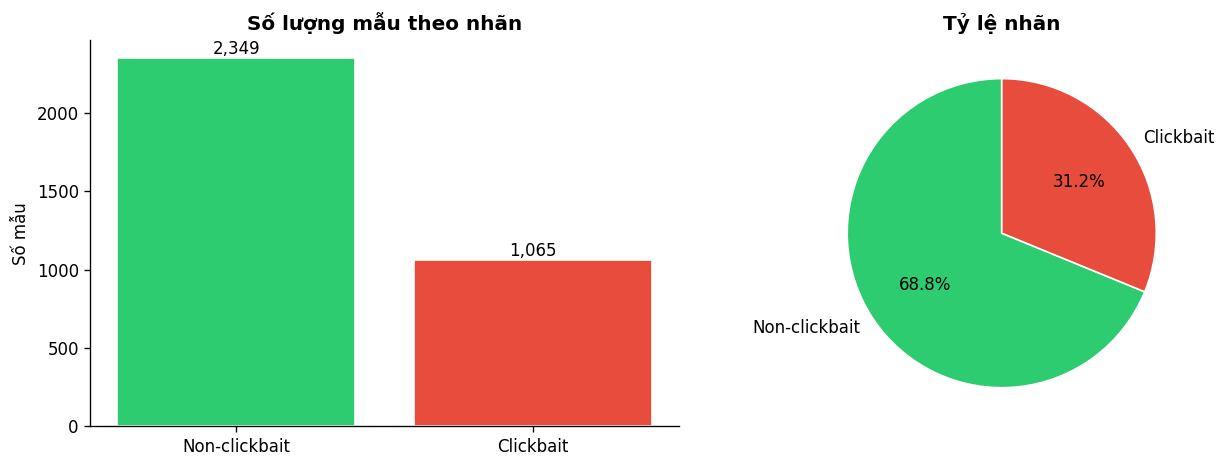

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

plot_colors = [PALETTE.get(k, '#999999') for k in vc.index]
bars = axes[0].bar(vc.index, vc.values, color=plot_colors, edgecolor='white')
axes[0].set_title('Số lượng mẫu theo nhãn', fontweight='bold')
axes[0].set_ylabel('Số mẫu')
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{int(val):,}', ha='center', va='bottom')

axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%', colors=plot_colors,
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Tỷ lệ nhãn', fontweight='bold')

plt.tight_layout()
plt.show()

## 6.Phân tích theo Source (Nguồn báo)

In [20]:
global_cb_rate = df['label'].mean() * 100

source_cb = df.groupby('source')['label'].agg(['sum', 'count'])
source_cb['cb_rate'] = (source_cb['sum'] / source_cb['count'] * 100).round(2)
source_cb['delta_vs_global'] = (source_cb['cb_rate'] - global_cb_rate).round(2)
source_cb = source_cb.reset_index().rename(columns={'sum': 'n_clickbait', 'count': 'n_total'})
source_cb['risk_level'] = np.select(
    [
        (source_cb['n_total'] >= 50) & (source_cb['delta_vs_global'].abs() >= 20),
        (source_cb['n_total'] >= 50) & (source_cb['delta_vs_global'].abs() >= 10),
    ],
    ['High', 'Medium'],
    default='Low',
)
source_cb = source_cb.sort_values('cb_rate', ascending=False)

print(f'Tỷ lệ clickbait toàn dataset: {global_cb_rate:.2f}%')
display(source_cb)

high_risk_sources = source_cb[source_cb['risk_level'] == 'High']['source'].tolist()
print(f'Nguồn có rủi ro source bias cao: {high_risk_sources if high_risk_sources else "Không có"}')

Tỷ lệ clickbait toàn dataset: 31.20%


,source,n_clickbait,n_total,cb_rate,delta_vs_global,risk_level
2,Kênh14,40,52,76.92,45.72,High
3,SaoStar,186,286,65.03,33.83,High
0,24h,248,564,43.97,12.77,Medium
6,VietNamNet,113,356,31.74,0.54,Low
4,Thanh Niên,172,576,29.86,-1.34,Low
5,Tuổi Trẻ,70,241,29.05,-2.15,Low
1,Báo Mới,148,731,20.25,-10.95,Medium
7,VnExpress,88,608,14.47,-16.73,Medium


Nguồn có rủi ro source bias cao: ['Kênh14', 'SaoStar']


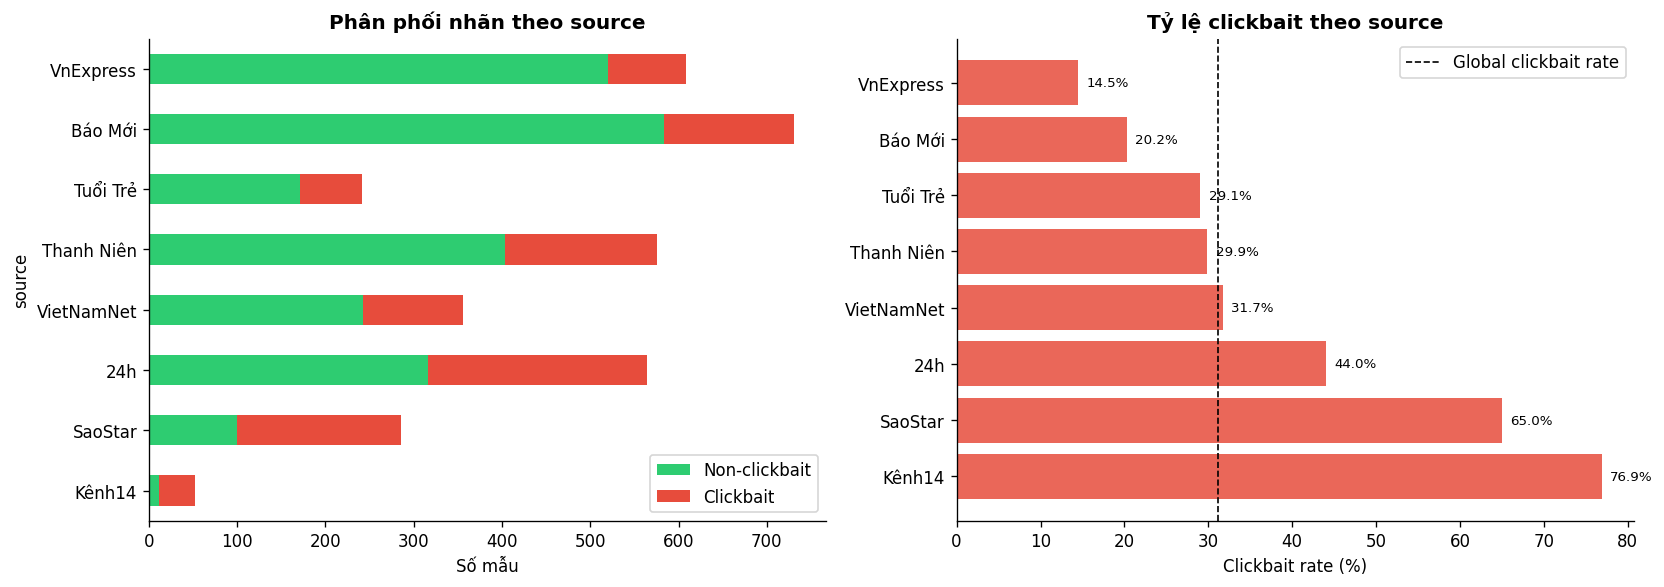

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

source_pivot = df.groupby(['source', 'label_str']).size().unstack(fill_value=0)
source_pivot = source_pivot.reindex(source_cb['source'])
source_pivot[['Non-clickbait', 'Clickbait']].plot(
    kind='barh', stacked=True, color=[NCB_COLOR, CB_COLOR], ax=axes[0]
)
axes[0].set_title('Phân phối nhãn theo source', fontweight='bold')
axes[0].set_xlabel('Số mẫu')
axes[0].legend(loc='lower right')

bars = axes[1].barh(source_cb['source'], source_cb['cb_rate'], color=CB_COLOR, alpha=0.85)
axes[1].axvline(global_cb_rate, color='black', linestyle='--', linewidth=1, label='Global clickbait rate')
axes[1].set_title('Tỷ lệ clickbait theo source', fontweight='bold')
axes[1].set_xlabel('Clickbait rate (%)')
axes[1].legend()
for bar, val in zip(bars, source_cb['cb_rate']):
    axes[1].text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 7.Phân tích theo Category (Chủ đề)

*Mục tiêu:* phát hiện category bias và xác định category nào đủ mẫu cho category-held-out evaluation.

In [25]:
cat_cb = df.groupby('category')['label'].agg(['sum', 'count'])
cat_cb['cb_rate'] = (cat_cb['sum'] / cat_cb['count'] * 100).round(2)
cat_cb['delta_vs_global'] = (cat_cb['cb_rate'] - global_cb_rate).round(2)
cat_cb = cat_cb.reset_index().rename(columns={'sum': 'n_clickbait', 'count': 'n_total'})
cat_cb['enough_for_holdout'] = cat_cb['n_total'] >= 100
cat_cb['risk_level'] = np.select(
    [
        (cat_cb['n_total'] >= 100) & (cat_cb['delta_vs_global'].abs() >= 20),
        (cat_cb['n_total'] >= 100) & (cat_cb['delta_vs_global'].abs() >= 10),
    ],
    ['High', 'Medium'],
    default='Low',
)
cat_cb = cat_cb.sort_values('n_total', ascending=False)

display(cat_cb)

small_categories = cat_cb[~cat_cb['enough_for_holdout']]['category'].tolist()
print(f'Category dưới 100 mẫu, chỉ nên báo cáo thận trọng nếu held-out: {small_categories}')

,category,n_clickbait,n_total,cb_rate,delta_vs_global,enough_for_holdout,risk_level
6,Other,300,1117,26.86,-4.34,True,Low
9,Thể thao,84,325,25.85,-5.35,True,Low
7,Quốc tế,60,241,24.90,-6.30,True,Low
4,Giải trí & Showbiz,168,238,70.59,39.39,True,High
8,Sức khỏe & Đời sống,130,228,57.02,25.82,True,High
1,Công nghệ & Khoa học,78,220,35.45,4.25,True,Low
5,Kinh doanh & Kinh tế,64,204,31.37,0.17,True,Low
10,Tin tức tổng hợp,8,197,4.06,-27.14,True,High
0,Chính trị & An ninh,29,173,16.76,-14.44,True,Medium
3,Giáo dục & Học đường,37,160,23.12,-8.08,True,Low


Category dưới 100 mẫu, chỉ nên báo cáo thận trọng nếu held-out: ['Văn hóa & Nghệ thuật']


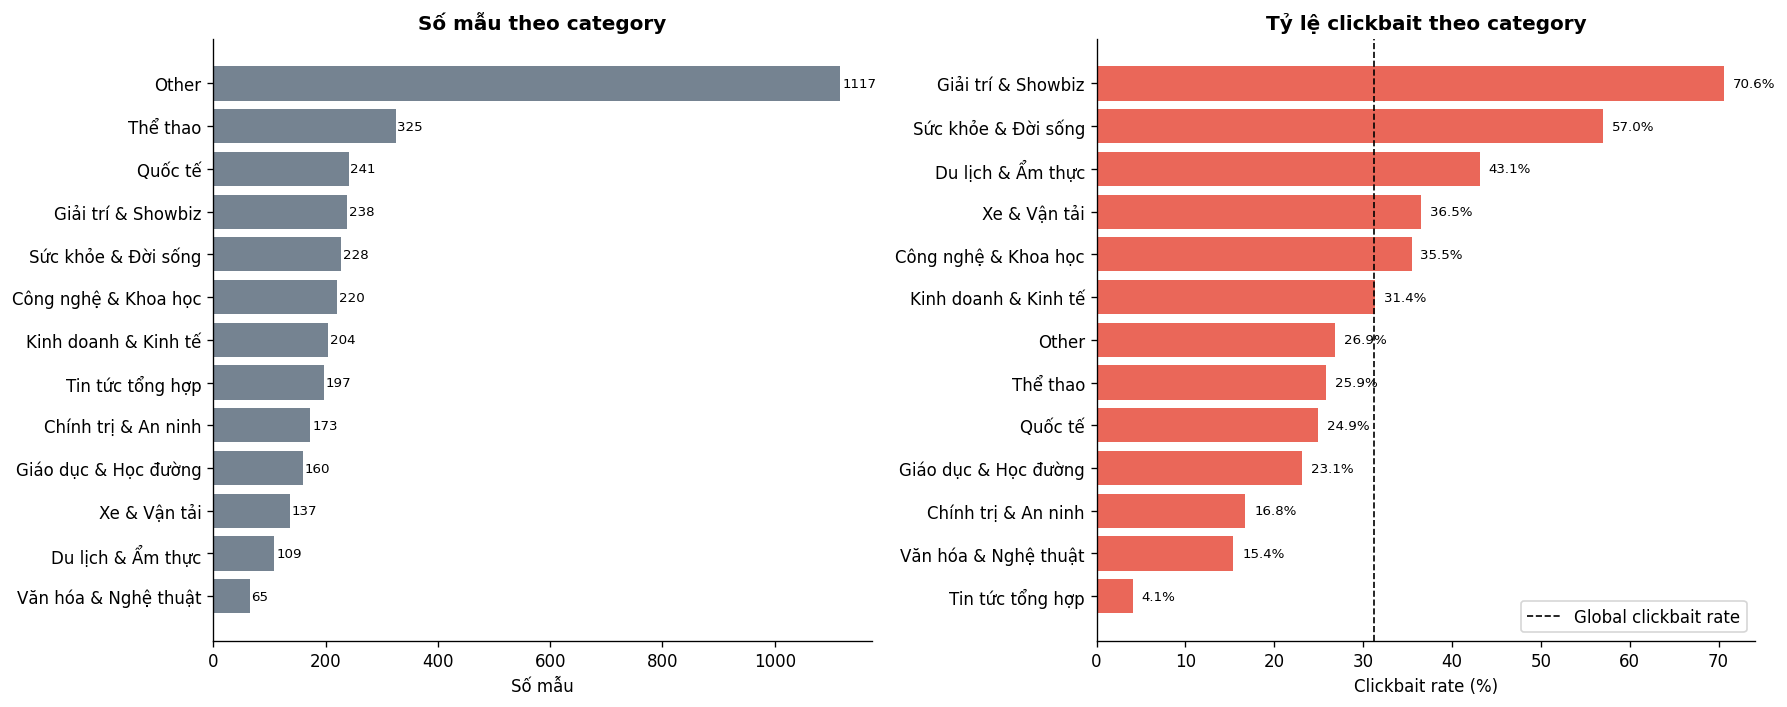

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cat_sorted = cat_cb.sort_values('n_total')
bars = axes[0].barh(cat_sorted['category'], cat_sorted['n_total'], color=NEUTRAL_COLOR, alpha=0.85)
axes[0].set_title('Số mẫu theo category', fontweight='bold')
axes[0].set_xlabel('Số mẫu')
for bar, val in zip(bars, cat_sorted['n_total']):
    axes[0].text(val + 3, bar.get_y() + bar.get_height()/2, f'{int(val)}', va='center', fontsize=8)

cat_rate_sorted = cat_cb.sort_values('cb_rate')
bars = axes[1].barh(cat_rate_sorted['category'], cat_rate_sorted['cb_rate'], color=CB_COLOR, alpha=0.85)
axes[1].axvline(global_cb_rate, color='black', linestyle='--', linewidth=1, label='Global clickbait rate')
axes[1].set_title('Tỷ lệ clickbait theo category', fontweight='bold')
axes[1].set_xlabel('Clickbait rate (%)')
axes[1].legend()
for bar, val in zip(bars, cat_rate_sorted['cb_rate']):
    axes[1].text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 8.Phân tích theo Thời gian (publish_datetime)

In [27]:
def parse_vn_datetime(date_str):
    if pd.isna(date_str):
        return pd.NaT

    clean_str = str(date_str).strip()

    if 'T' in clean_str:
        try:
            dt = pd.to_datetime(clean_str, utc=True)
            return dt.tz_localize(None) if dt.tzinfo is None else dt.tz_convert(None)
        except Exception:
            pass

    days_vn = [
        'Thứ Hai', 'Thứ Ba', 'Thứ Tư', 'Thứ Năm', 'Thứ Sáu', 'Thứ Bảy', 'Chủ Nhật',
        'Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7',
    ]
    for d in days_vn:
        clean_str = clean_str.replace(d, '')
    clean_str = clean_str.strip().strip(',').strip()

    try:
        return pd.to_datetime(clean_str, dayfirst=True, errors='raise')
    except Exception:
        pass

    try:
        return dateutil.parser.parse(clean_str, dayfirst=True).replace(tzinfo=None)
    except Exception:
        return pd.NaT


df['publish_datetime_raw'] = df['publish_datetime']
df['publish_dt'] = df['publish_datetime_raw'].apply(parse_vn_datetime)
df['year'] = df['publish_dt'].dt.year
df['month'] = df['publish_dt'].dt.month
df['hour'] = df['publish_dt'].dt.hour
df['dayofweek'] = df['publish_dt'].dt.dayofweek
df['yearmonth'] = df['publish_dt'].dt.to_period('M')

n_valid_time = df['publish_dt'].notna().sum()
n_missing_time = df['publish_dt'].isna().sum()
print(f'Tổng số dòng: {len(df):,}')
print(f'Số dòng parse được thời gian: {n_valid_time:,}')
print(f'Số dòng thiếu/không parse được thời gian: {n_missing_time:,}')

time_df = df.dropna(subset=['publish_dt']).copy()
year_dist = time_df.groupby(['year', 'label_str']).size().unstack(fill_value=0)
print('\nPhân phối theo năm:')
display(year_dist)

year_summary = time_df.groupby('year')['label'].agg(['count', 'sum'])
year_summary['cb_rate'] = (year_summary['sum'] / year_summary['count'] * 100).round(2)
year_summary = year_summary.rename(columns={'count': 'n_total', 'sum': 'n_clickbait'})
print('\nTỷ lệ clickbait theo năm:')
display(year_summary)

if len(year_summary) > 0:
    largest_year_share = year_summary['n_total'].max() / year_summary['n_total'].sum()
    if largest_year_share >= 0.8:
        print('Nhận xét temporal split: dữ liệu tập trung mạnh vào một năm; nên dùng chronological split hoặc báo cáo temporal analysis như exploratory.')
    else:
        print('Nhận xét temporal split: phân phối năm đủ đa dạng hơn, có thể cân nhắc train-on-past/test-on-future.')

failed_rows = df[df['publish_dt'].isna()]
if len(failed_rows) > 0:
    print(f'\nVí dụ dòng không parse được thời gian: {len(failed_rows)} dòng')
    display(failed_rows[['id', 'publish_datetime_raw', 'source', 'category', 'label_str']].head(10))

Tổng số dòng: 3,414
Số dòng parse được thời gian: 3,383
Số dòng thiếu/không parse được thời gian: 31

Phân phối theo năm:


label_str,Clickbait,Non-clickbait
year,,
2021.0,0,1
2022.0,1,6
2023.0,1,3
2024.0,4,27
2025.0,1047,2293



Tỷ lệ clickbait theo năm:


,n_total,n_clickbait,cb_rate
year,,,
2021.0,1,0,0.00
2022.0,7,1,14.29
2023.0,4,1,25.00
2024.0,31,4,12.90
2025.0,3340,1047,31.35


Nhận xét temporal split: dữ liệu tập trung mạnh vào một năm; nên dùng chronological split hoặc báo cáo temporal analysis như exploratory.

Ví dụ dòng không parse được thời gian: 31 dòng


,id,publish_datetime_raw,source,category,label_str
13,article_0019,NaN,VnExpress,Tin tức tổng hợp,Non-clickbait
198,article_0246,NaN,Báo Mới,Thể thao,Non-clickbait
199,article_0247,NaN,Báo Mới,Thể thao,Non-clickbait
200,article_0248,NaN,Báo Mới,Thể thao,Non-clickbait
201,article_0249,NaN,Báo Mới,Thể thao,Non-clickbait
202,article_0250,NaN,Báo Mới,Thể thao,Non-clickbait
205,article_0254,NaN,Báo Mới,Thể thao,Non-clickbait
206,article_0255,NaN,Báo Mới,Thể thao,Non-clickbait
207,article_0256,NaN,Báo Mới,Thể thao,Non-clickbait
208,article_0257,NaN,Báo Mới,Thể thao,Non-clickbait


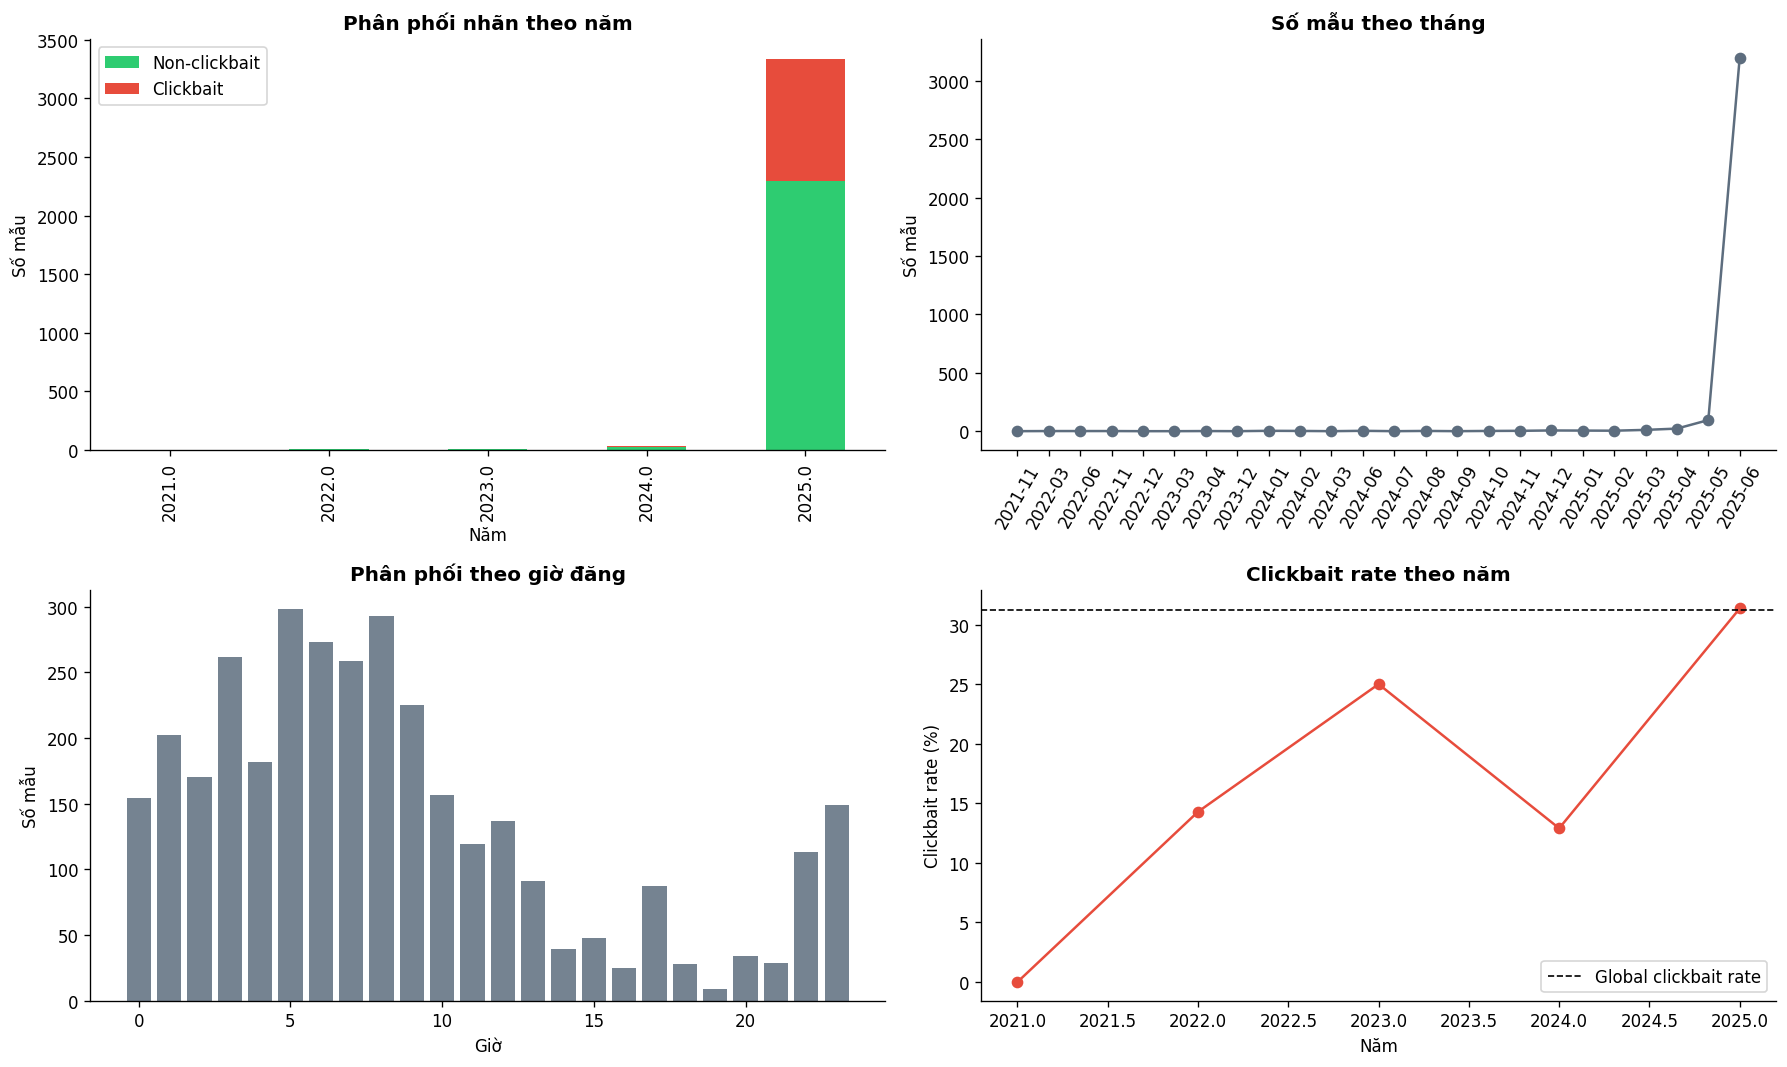

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

plot_cols = [c for c in ['Non-clickbait', 'Clickbait'] if c in year_dist.columns]
year_dist[plot_cols].plot(kind='bar', stacked=True, color=[NCB_COLOR, CB_COLOR], ax=axes[0, 0])
axes[0, 0].set_title('Phân phối nhãn theo năm', fontweight='bold')
axes[0, 0].set_xlabel('Năm')
axes[0, 0].set_ylabel('Số mẫu')
axes[0, 0].legend()

monthly = time_df.groupby('yearmonth').size()
monthly.index = monthly.index.astype(str)
axes[0, 1].plot(monthly.index, monthly.values, marker='o', color=NEUTRAL_COLOR)
axes[0, 1].set_title('Số mẫu theo tháng', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=60)
axes[0, 1].set_ylabel('Số mẫu')

hour_dist = time_df.groupby('hour').size()
axes[1, 0].bar(hour_dist.index, hour_dist.values, color=NEUTRAL_COLOR, alpha=0.85)
axes[1, 0].set_title('Phân phối theo giờ đăng', fontweight='bold')
axes[1, 0].set_xlabel('Giờ')
axes[1, 0].set_ylabel('Số mẫu')

if len(year_summary) > 0:
    axes[1, 1].plot(year_summary.index.astype(int), year_summary['cb_rate'], marker='o', color=CB_COLOR)
    axes[1, 1].axhline(global_cb_rate, color='black', linestyle='--', linewidth=1, label='Global clickbait rate')
    axes[1, 1].set_title('Clickbait rate theo năm', fontweight='bold')
    axes[1, 1].set_xlabel('Năm')
    axes[1, 1].set_ylabel('Clickbait rate (%)')
    axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 9.Phân tích Văn bản — Title

In [29]:
df['title_char_len'] = df['title'].fillna('').str.len()
df['title_word_len'] = df['title'].fillna('').str.split().str.len()

title_len_summary = []
for feat in ['title_char_len', 'title_word_len']:
    cb_v = df[df['label'] == 1][feat]
    ncb_v = df[df['label'] == 0][feat]
    t_stat, p_val = stats.ttest_ind(cb_v, ncb_v, equal_var=False)
    title_len_summary.append({
        'feature': feat,
        'clickbait_mean': cb_v.mean(),
        'non_clickbait_mean': ncb_v.mean(),
        'difference_cb_minus_ncb': cb_v.mean() - ncb_v.mean(),
        'p_value': p_val,
    })

title_len_summary = pd.DataFrame(title_len_summary)
display(title_len_summary.round(4))

,feature,clickbait_mean,non_clickbait_mean,difference_cb_minus_ncb,p_value
0,title_char_len,65.6723,67.0809,-1.4086,0.0772
1,title_word_len,14.8113,15.0656,-0.2543,0.1575


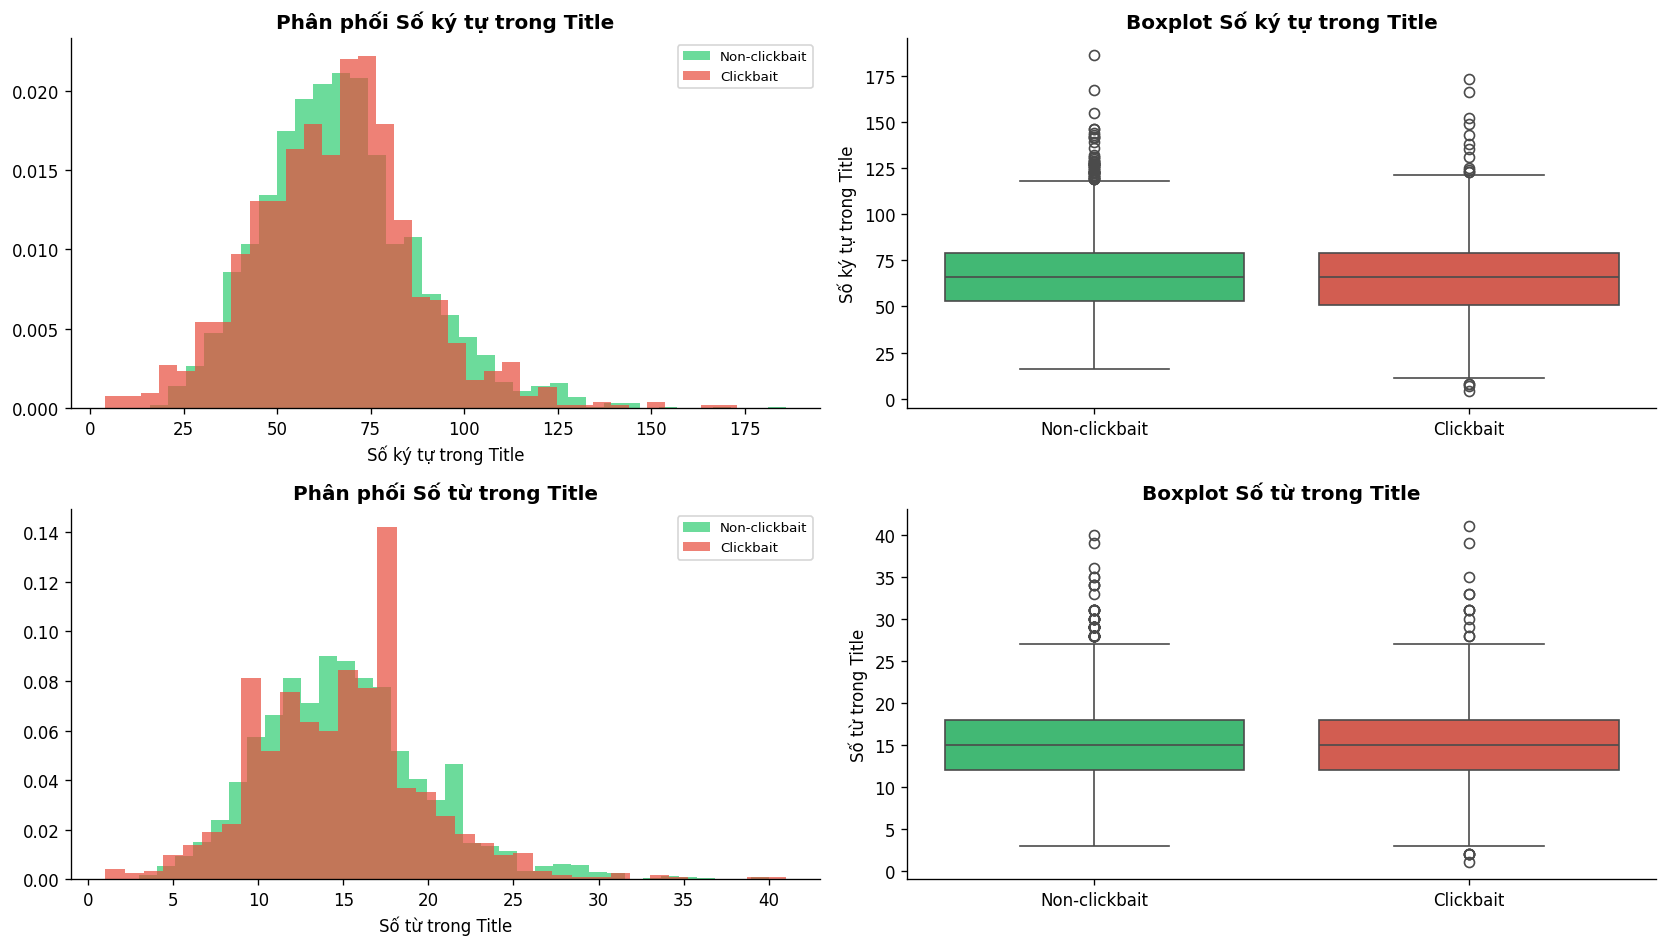

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, feat, label_name in [
    (0, 'title_char_len', 'Số ký tự trong Title'),
    (1, 'title_word_len', 'Số từ trong Title'),
]:
    cb_v = df[df['label'] == 1][feat]
    ncb_v = df[df['label'] == 0][feat]

    axes[row, 0].hist(ncb_v, bins=35, alpha=0.7, color=NCB_COLOR, label='Non-clickbait', density=True)
    axes[row, 0].hist(cb_v, bins=35, alpha=0.7, color=CB_COLOR, label='Clickbait', density=True)
    axes[row, 0].set_title(f'Phân phối {label_name}', fontweight='bold')
    axes[row, 0].set_xlabel(label_name)
    axes[row, 0].legend(fontsize=8)

    sns.boxplot(data=df, x='label_str', y=feat, palette=PALETTE, ax=axes[row, 1])
    axes[row, 1].set_title(f'Boxplot {label_name}', fontweight='bold')
    axes[row, 1].set_xlabel('')
    axes[row, 1].set_ylabel(label_name)

plt.tight_layout()
plt.show()

In [31]:
def get_top_ngrams(texts, n=1, top_k=20):
    vec = CountVectorizer(ngram_range=(n, n), max_features=5000, token_pattern=r'(?u)\b\w+\b')
    X = vec.fit_transform(texts.fillna('').astype(str))
    freqs = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    top_idx = freqs.argsort()[::-1][:top_k]
    return [(vocab[i], int(freqs[i])) for i in top_idx]

cb_titles = df[df['label'] == 1]['title'].fillna('')
ncb_titles = df[df['label'] == 0]['title'].fillna('')

top_cb_1 = get_top_ngrams(cb_titles, n=1, top_k=15)
top_ncb_1 = get_top_ngrams(ncb_titles, n=1, top_k=15)
top_cb_2 = get_top_ngrams(cb_titles, n=2, top_k=15)
top_ncb_2 = get_top_ngrams(ncb_titles, n=2, top_k=15)

print('Top unigrams - Clickbait:')
display(pd.DataFrame(top_cb_1, columns=['ngram', 'count']))
print('Top unigrams - Non-clickbait:')
display(pd.DataFrame(top_ncb_1, columns=['ngram', 'count']))

Top unigrams - Clickbait:


,ngram,count
0,người,150
1,của,150
2,báo,137
3,có,124
4,không,108
5,khi,90
6,bị,86
7,ở,84
8,nam,81
9,xe,76


Top unigrams - Non-clickbait:


,ngram,count
0,báo,578
1,công,332
2,nam,261
3,của,224
4,việt,213
5,ở,201
6,người,196
7,đồng,183
8,2025,178
9,và,166


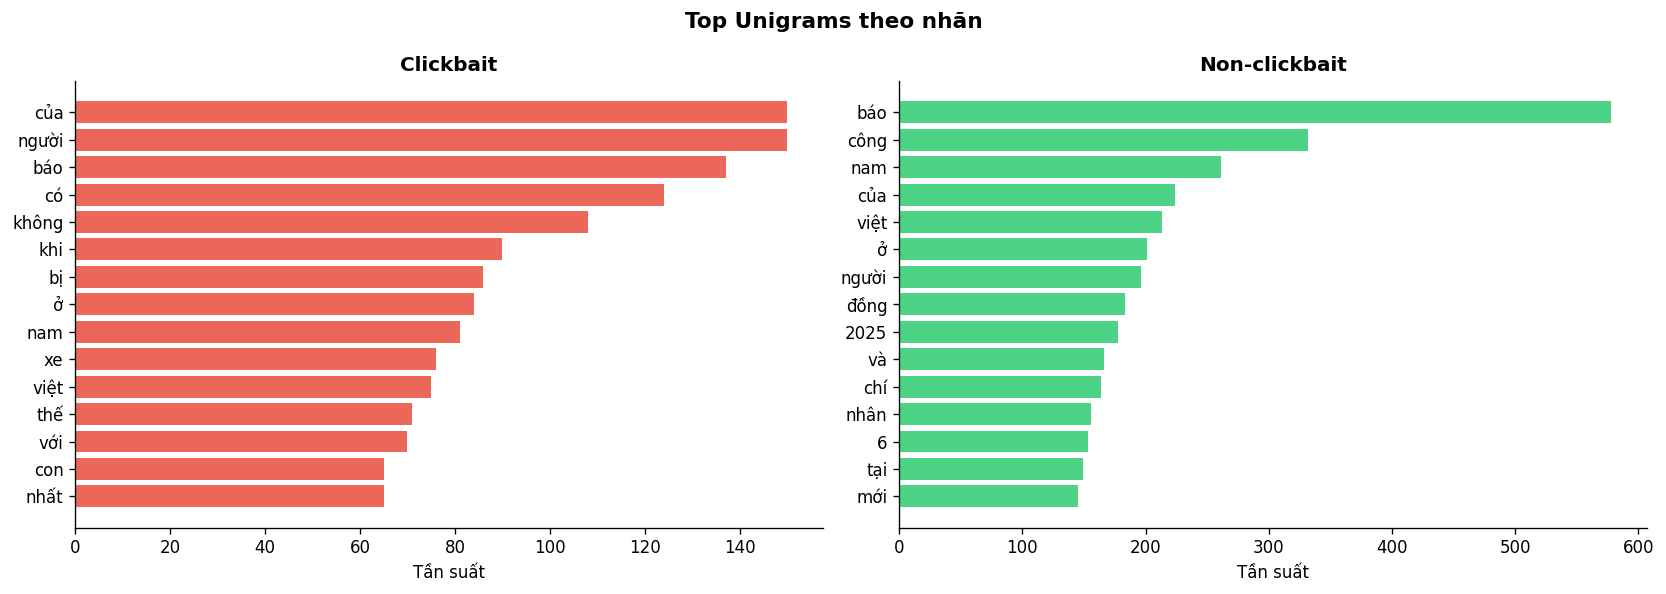

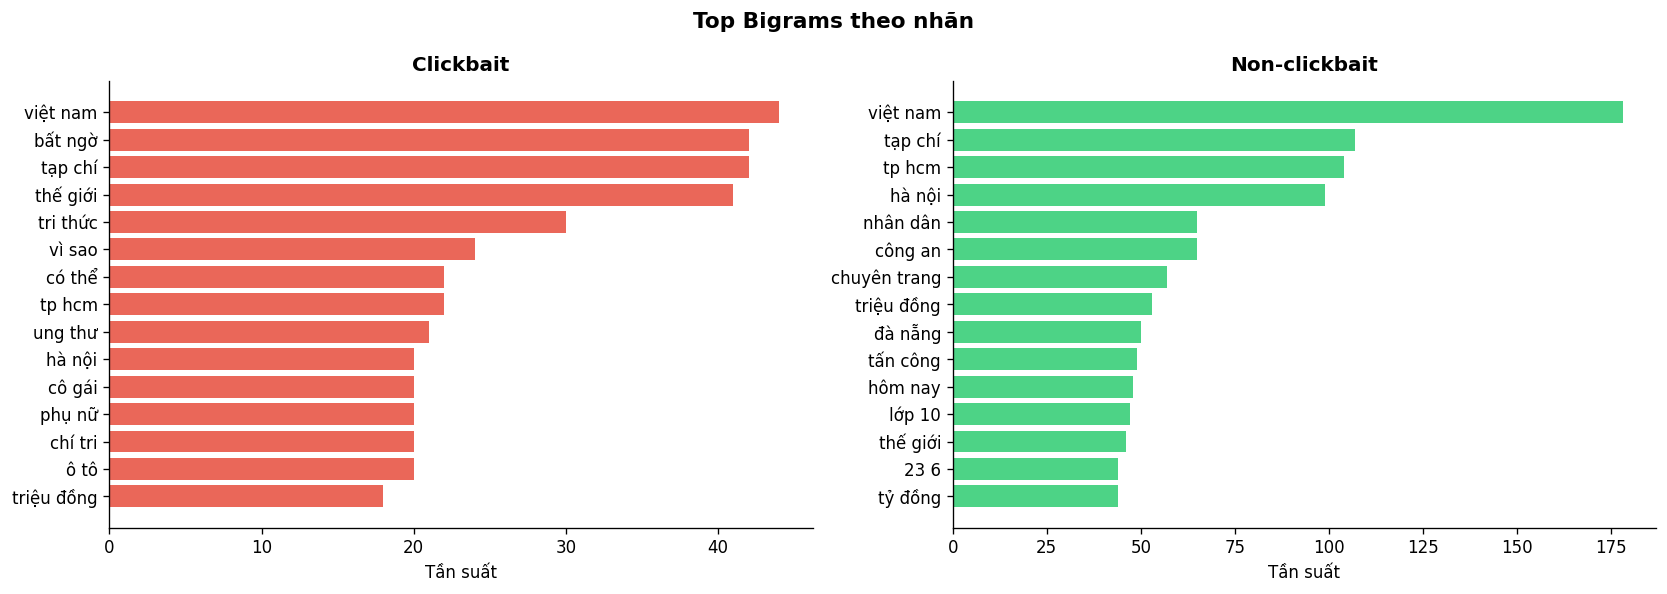

In [32]:
def plot_top_ngrams(top_cb, top_ncb, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, data, label, color in [
        (axes[0], top_cb, 'Clickbait', CB_COLOR),
        (axes[1], top_ncb, 'Non-clickbait', NCB_COLOR),
    ]:
        data_df = pd.DataFrame(data, columns=['ngram', 'count']).sort_values('count')
        ax.barh(data_df['ngram'], data_df['count'], color=color, alpha=0.85)
        ax.set_title(label, fontweight='bold')
        ax.set_xlabel('Tần suất')
    plt.suptitle(title, fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()

plot_top_ngrams(top_cb_1, top_ncb_1, 'Top Unigrams theo nhãn')
plot_top_ngrams(top_cb_2, top_ncb_2, 'Top Bigrams theo nhãn')

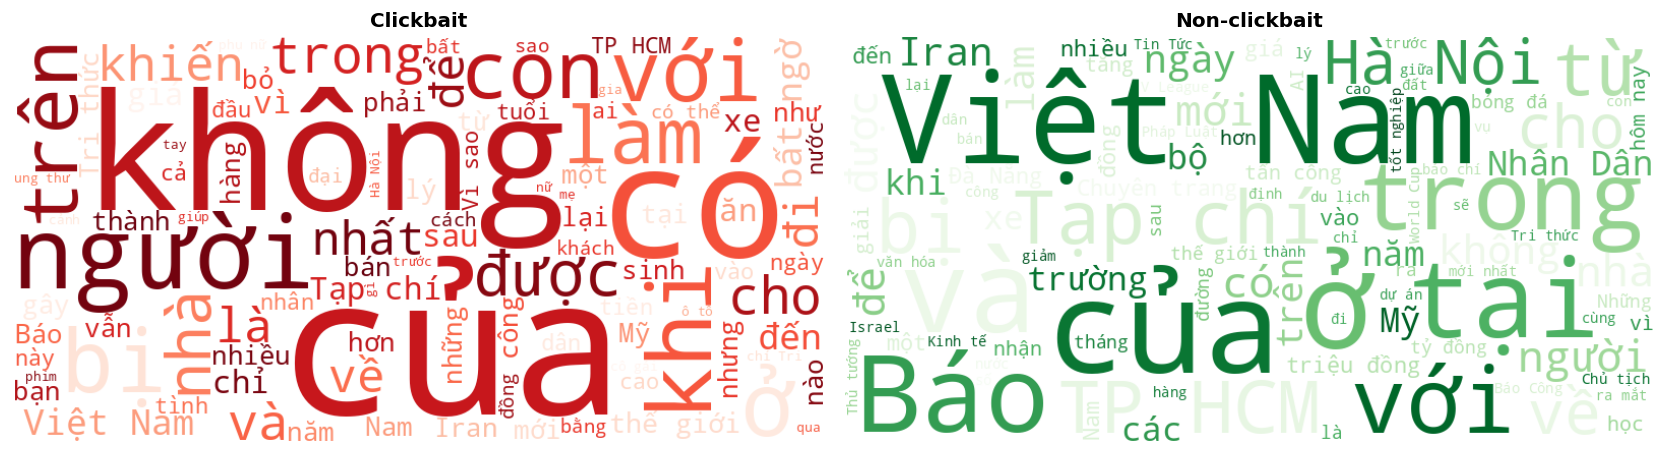

In [34]:
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, texts, label, cmap_name in [
        (axes[0], ' '.join(cb_titles), 'Clickbait', 'Reds'),
        (axes[1], ' '.join(ncb_titles), 'Non-clickbait', 'Greens'),
    ]:
        wc = WordCloud(width=800, height=400, background_color='white', colormap=cmap_name,
                       max_words=100).generate(texts)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(label, fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f'Something failed: {exc}')

## 10.Đặc trưng dấu câu và cue bề mặt

In [35]:
def count_pattern(text, pattern):
    return len(re.findall(pattern, str(text)))

QUOTE_PATTERN = r"[\"'“”‘’]"

df['title_n_exclaim'] = df['title'].apply(lambda x: count_pattern(x, r'!'))
df['title_n_question'] = df['title'].apply(lambda x: count_pattern(x, r'\?'))
df['title_n_ellipsis'] = df['title'].apply(lambda x: count_pattern(x, r'\.{3}|…'))
df['title_n_number'] = df['title'].apply(lambda x: count_pattern(x, r'\d+'))
df['title_has_caps'] = df['title'].apply(lambda x: int(bool(re.search(r'[A-Z]{2,}', str(x)))))
df['title_n_quote'] = df['title'].apply(lambda x: count_pattern(x, QUOTE_PATTERN))

punc_cols = [
    'title_n_exclaim', 'title_n_question', 'title_n_ellipsis',
    'title_n_number', 'title_has_caps', 'title_n_quote'
]

punc_by_label = df.groupby('label_str')[punc_cols].mean().T
punc_by_label.columns.name = None
print('Trung bình đặc trưng dấu câu theo nhãn:')
display(punc_by_label.round(4))

Trung bình đặc trưng dấu câu theo nhãn:


,Clickbait,Non-clickbait
title_n_exclaim,0.0178,0.0030
title_n_question,0.2056,0.0341
title_n_ellipsis,0.0094,0.0021
title_n_number,0.4291,0.6667
title_has_caps,0.1549,0.2524
title_n_quote,0.6920,0.2393


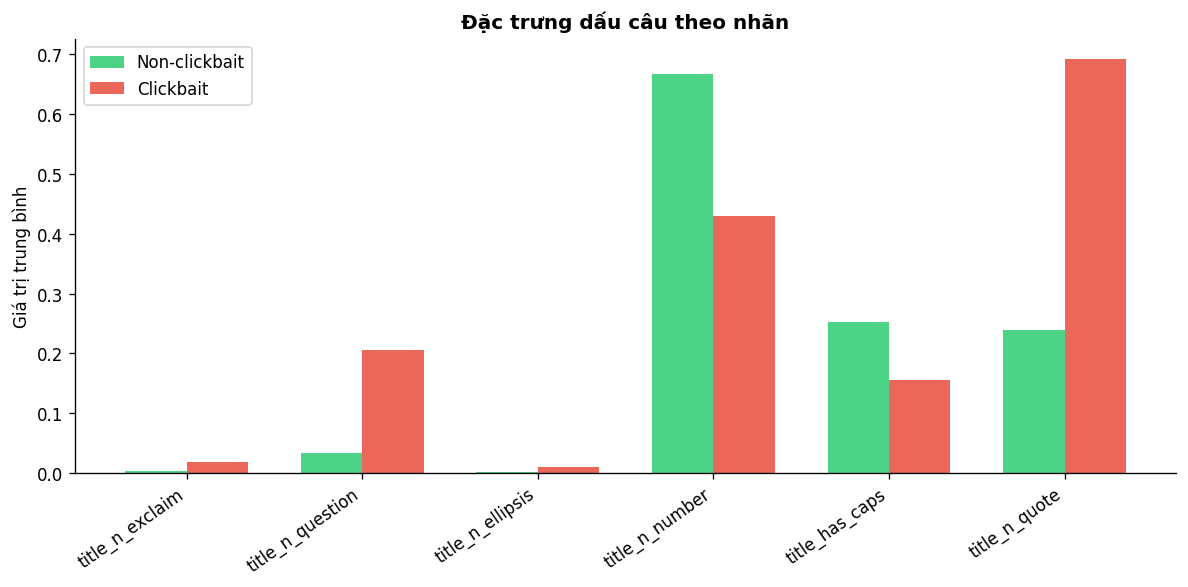

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(punc_cols))
w = 0.35
labels_order = ['Non-clickbait', 'Clickbait']

for i, (lbl, col) in enumerate([(labels_order[0], NCB_COLOR), (labels_order[1], CB_COLOR)]):
    vals = punc_by_label[lbl].reindex(punc_cols).values
    ax.bar(x + (i - 0.5) * w, vals, width=w, label=lbl, color=col, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(punc_cols, rotation=35, ha='right')
ax.set_ylabel('Giá trị trung bình')
ax.set_title('Đặc trưng dấu câu theo nhãn', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 11.Phân tích Văn bản — lead_paragraph (Sapo)

,feature,clickbait_mean,non_clickbait_mean,difference_cb_minus_ncb,p_value
0,lead_char_len,149.5333,168.2865,-18.7532,0.0000
1,lead_word_len,32.9596,36.6620,-3.7024,0.0000
2,lead_title_ratio,2.5757,2.6365,-0.0608,0.3108


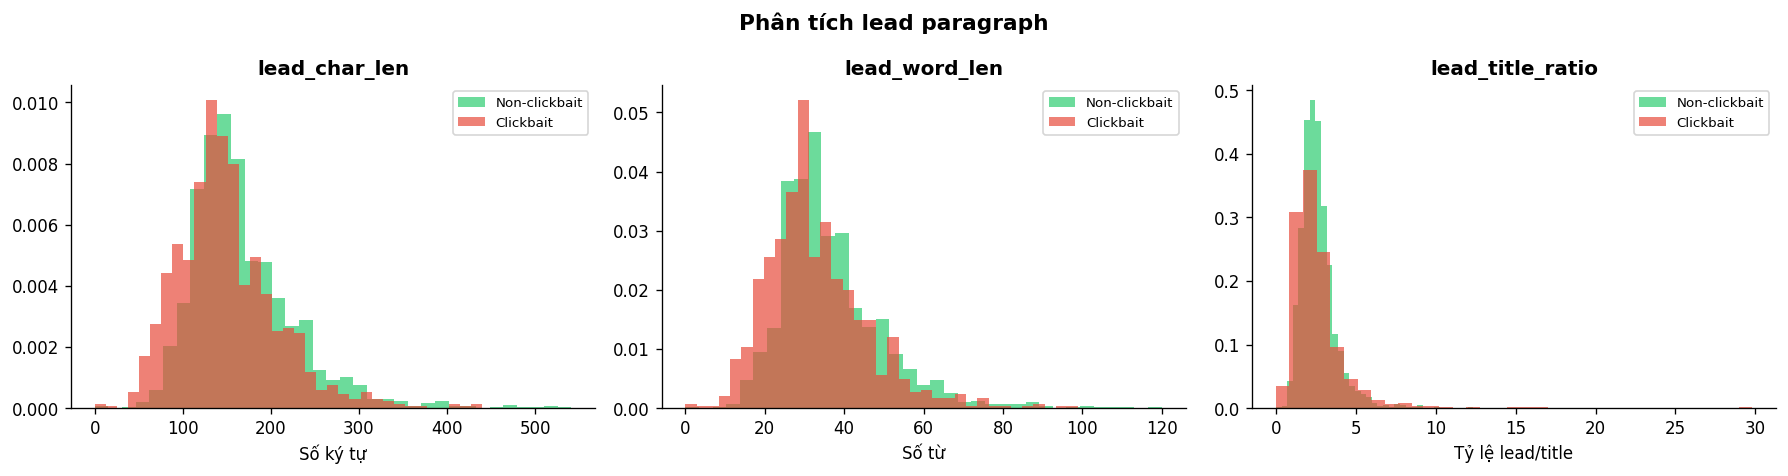

In [37]:
df['lead_char_len'] = df['lead_paragraph'].fillna('').str.len()
df['lead_word_len'] = df['lead_paragraph'].fillna('').str.split().str.len()
df['lead_title_ratio'] = df['lead_char_len'] / (df['title_char_len'] + 1)

lead_summary = []
for feat in ['lead_char_len', 'lead_word_len', 'lead_title_ratio']:
    cb_v = df[df['label'] == 1][feat]
    ncb_v = df[df['label'] == 0][feat]
    t_stat, p_val = stats.ttest_ind(cb_v, ncb_v, equal_var=False)
    lead_summary.append({
        'feature': feat,
        'clickbait_mean': cb_v.mean(),
        'non_clickbait_mean': ncb_v.mean(),
        'difference_cb_minus_ncb': cb_v.mean() - ncb_v.mean(),
        'p_value': p_val,
    })

lead_summary = pd.DataFrame(lead_summary)
display(lead_summary.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat, xlabel in [
    (axes[0], 'lead_char_len', 'Số ký tự'),
    (axes[1], 'lead_word_len', 'Số từ'),
    (axes[2], 'lead_title_ratio', 'Tỷ lệ lead/title'),
]:
    cb_v = df[df['label'] == 1][feat]
    ncb_v = df[df['label'] == 0][feat]
    ax.hist(ncb_v, bins=35, alpha=0.7, color=NCB_COLOR, label='Non-clickbait', density=True)
    ax.hist(cb_v, bins=35, alpha=0.7, color=CB_COLOR, label='Clickbait', density=True)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.legend(fontsize=8)

plt.suptitle('Phân tích lead paragraph', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## 12.Feature Engineering cho explainability và leakage audit

Phân tách rõ:

- `MODEL_SAFE_FEATS`: lexical/surface features có thể dùng cho ablation hoặc explainability.
- `LEAKAGE_AUDIT_FEATS`: metadata encoding chỉ dùng để kiểm tra shortcut/leakage.
- `TARGET_RATE_DIAGNOSTICS`: tỷ lệ clickbait theo source/category, chỉ dùng mô tả bias; không dùng train model vì chứa thông tin label toàn dataset.

In [39]:
CB_KEYWORDS = [
    'sốc', 'kinh hoàng', 'khó tin', 'bất ngờ', 'không ngờ',
    'choáng', 'ngã ngửa', 'xúc động', 'xót xa', 'phẫn nộ',
    'bí mật', 'tiết lộ', 'hé lộ', 'lộ diện', 'phát hiện',
    'sự thật', 'thực ra', 'hóa ra',
    'vì sao', 'tại sao', 'lý do', 'như thế nào', 'ra sao',
    'gây sốt', 'gây bão', 'gây tranh cãi', 'gây chú ý',
    'viral', 'hot', 'nóng',
    'cảnh báo', 'nguy hiểm', 'đáng lo',
    'bí quyết', 'cách', 'mẹo', 'điều bạn',
]

AMBIGUOUS_CUES = [
    'này', 'kia', 'ấy', 'đó', 'người này', 'điều này', 'thứ này',
    'lý do', 'sự thật', 'bí mật', 'không ngờ', 'bất ngờ',
]

CURIOSITY_GAP_CUES = [
    'vì sao', 'tại sao', 'lý do', 'sự thật', 'bí mật', 'hé lộ',
    'điều gì', 'ra sao', 'như thế nào', 'không ngờ',
]

def count_keywords(text, keywords):
    t = str(text).lower()
    return sum(1 for kw in keywords if kw in t)

def starts_with_number(text):
    return int(bool(re.match(r'^\d+', str(text).strip())))

def has_superlative(text):
    superlatives = ['nhất', 'tốt nhất', 'đầu tiên', 'duy nhất', 'số 1']
    t = str(text).lower()
    return int(any(s in t for s in superlatives))

def count_negative(text):
    neg_words = ['không', 'chưa', 'chẳng', 'đừng', 'cấm', 'nguy hiểm']
    t = str(text).lower()
    return sum(1 for w in neg_words if w in t)

def avg_word_len(text):
    words = str(text).split()
    return np.mean([len(w) for w in words]) if words else 0

# Title lexical/surface features
df['title_n_cb_keywords'] = df['title'].apply(lambda x: count_keywords(x, CB_KEYWORDS))
df['title_n_ambiguous_cues'] = df['title'].apply(lambda x: count_keywords(x, AMBIGUOUS_CUES))
df['title_n_curiosity_gap_cues'] = df['title'].apply(lambda x: count_keywords(x, CURIOSITY_GAP_CUES))
df['title_starts_with_num'] = df['title'].apply(starts_with_number)
df['title_has_superlative'] = df['title'].apply(has_superlative)
df['title_n_negative'] = df['title'].apply(count_negative)
df['title_avg_word_len'] = df['title'].apply(avg_word_len)
df['title_uppercase_ratio'] = df['title'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
)
df['title_ends_question'] = df['title'].apply(lambda x: int(str(x).strip().endswith('?')))
df['title_ends_ellipsis'] = df['title'].apply(
    lambda x: int(str(x).strip().endswith('...') or str(x).strip().endswith('…'))
)
df['title_is_listicle'] = df['title'].apply(lambda x: int(bool(re.match(r'^\d+\s+\w+', str(x).strip()))))
df['title_has_quote'] = df['title'].apply(lambda x: int(bool(re.search(QUOTE_PATTERN, str(x)))))
df['title_has_source_tag'] = df['title'].apply(
    lambda x: int(bool(re.search(
        r'\s[-–]\s*(Báo|Tạp chí|VTC|VnExpress|Tuổi Trẻ|Thanh Niên|Kênh14|SaoStar|24h)',
        str(x),
    )))
)
df['lead_n_cb_keywords'] = df['lead_paragraph'].fillna('').apply(lambda x: count_keywords(x, CB_KEYWORDS))

MODEL_SAFE_FEATS = [
    'title_char_len', 'title_word_len',
    'title_n_exclaim', 'title_n_question', 'title_n_ellipsis',
    'title_n_number', 'title_has_caps', 'title_n_quote',
    'title_n_cb_keywords', 'title_n_ambiguous_cues', 'title_n_curiosity_gap_cues',
    'title_starts_with_num', 'title_has_superlative', 'title_n_negative',
    'title_avg_word_len', 'title_uppercase_ratio',
    'title_ends_question', 'title_ends_ellipsis', 'title_is_listicle',
    'title_has_quote', 'title_has_source_tag',
    'lead_char_len', 'lead_word_len', 'lead_title_ratio', 'lead_n_cb_keywords',
]

# Metadata chỉ dùng cho leakage/domain shortcut audit.
df['source_encoded'] = df['source'].astype('category').cat.codes
df['category_encoded'] = df['category'].astype('category').cat.codes
LEAKAGE_AUDIT_FEATS = ['source_encoded', 'category_encoded']

# Diagnostics có sử dụng label toàn dataset, chỉ được dùng để mô tả bias.
source_cb_rate = df.groupby('source')['label'].mean()
category_cb_rate = df.groupby('category')['label'].mean()
df['source_cb_rate_diagnostic'] = df['source'].map(source_cb_rate)
df['category_cb_rate_diagnostic'] = df['category'].map(category_cb_rate)
TARGET_RATE_DIAGNOSTICS = ['source_cb_rate_diagnostic', 'category_cb_rate_diagnostic']

print(f'Số model-safe features: {len(MODEL_SAFE_FEATS)}')
print(f'Số leakage-audit features: {len(LEAKAGE_AUDIT_FEATS)}')

Số model-safe features: 25
Số leakage-audit features: 2


In [40]:
print(f'Feature engineering hoàn tất. Tổng số model-safe features: {len(MODEL_SAFE_FEATS)}')
display(df[MODEL_SAFE_FEATS].describe().T[['mean', 'std', 'min', 'max']].round(3))

Feature engineering hoàn tất. Tổng số model-safe features: 25


,mean,std,min,max
title_char_len,66.641,21.166,4.000,186.000
title_word_len,14.986,4.845,1.000,41.000
title_n_exclaim,0.008,0.087,0.000,1.000
title_n_question,0.088,0.285,0.000,2.000
title_n_ellipsis,0.004,0.066,0.000,1.000
title_n_number,0.593,0.929,0.000,7.000
title_has_caps,0.222,0.416,0.000,1.000
title_n_quote,0.380,0.838,0.000,6.000
title_n_cb_keywords,0.136,0.381,0.000,3.000
title_n_ambiguous_cues,0.075,0.282,0.000,2.000


In [41]:
print('Welch t-test (Clickbait vs Non-clickbait) cho từng model-safe feature:')
results = []

for feat in MODEL_SAFE_FEATS:
    cb_v = df[df['label'] == 1][feat].dropna()
    ncb_v = df[df['label'] == 0][feat].dropna()

    if cb_v.nunique() <= 1 and ncb_v.nunique() <= 1:
        t_stat, p_val = np.nan, np.nan
    else:
        t_stat, p_val = stats.ttest_ind(cb_v, ncb_v, equal_var=False)

    diff = cb_v.mean() - ncb_v.mean()
    results.append({
        'Feature': feat,
        'CB mean': round(cb_v.mean(), 3),
        'NCB mean': round(ncb_v.mean(), 3),
        'Diff CB-NCB': round(diff, 3),
        'Direction': 'Higher in CB' if diff > 0 else 'Higher in NCB',
        't-stat': round(t_stat, 3) if pd.notna(t_stat) else np.nan,
        'p-value': round(p_val, 6) if pd.notna(p_val) else np.nan,
        'Significant': 'YES' if pd.notna(p_val) and p_val < 0.05 else 'NO',
    })

results_df = pd.DataFrame(results).sort_values('t-stat', key=lambda s: s.abs(), ascending=False)
display(results_df)

Welch t-test (Clickbait vs Non-clickbait) cho từng model-safe feature:


,Feature,CB mean,NCB mean,Diff CB-NCB,Direction,t-stat,p-value,Significant
3,title_n_question,0.206,0.034,0.172,Higher in CB,13.118,0.000000,YES
19,title_has_quote,0.321,0.117,0.204,Higher in CB,12.964,0.000000,YES
7,title_n_quote,0.692,0.239,0.453,Higher in CB,12.858,0.000000,YES
8,title_n_cb_keywords,0.288,0.067,0.221,Higher in CB,12.856,0.000000,YES
15,title_uppercase_ratio,0.054,0.074,-0.019,Higher in NCB,-12.603,0.000000,YES
16,title_ends_question,0.172,0.032,0.140,Higher in CB,11.584,0.000000,YES
10,title_n_curiosity_gap_cues,0.096,0.012,0.084,Higher in CB,8.757,0.000000,YES
21,lead_char_len,149.533,168.287,-18.753,Higher in NCB,-8.693,0.000000,YES
9,title_n_ambiguous_cues,0.150,0.041,0.109,Higher in CB,8.507,0.000000,YES
22,lead_word_len,32.960,36.662,-3.702,Higher in NCB,-7.765,0.000000,YES


## 13.Correlation & Tổng kết

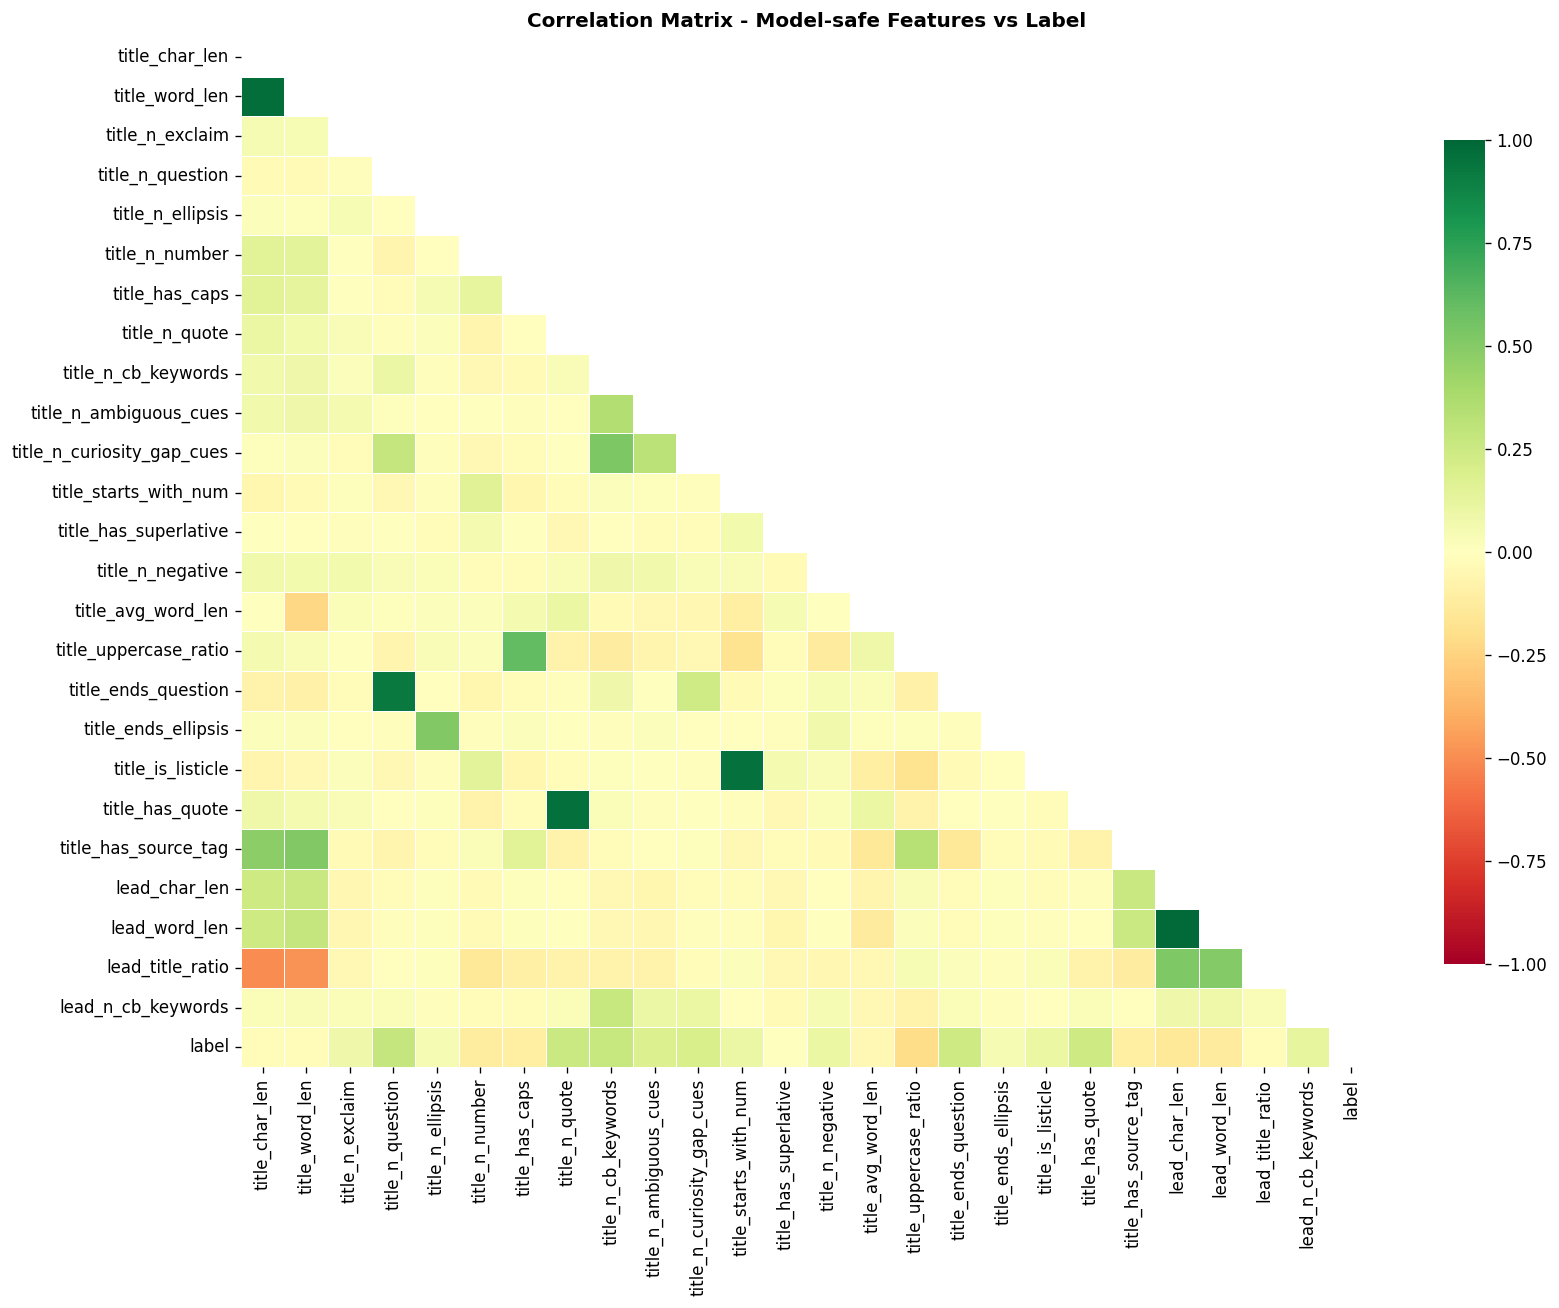

In [42]:
feat_cols = MODEL_SAFE_FEATS + ['label']
corr = df[feat_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.3,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix - Model-safe Features vs Label', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

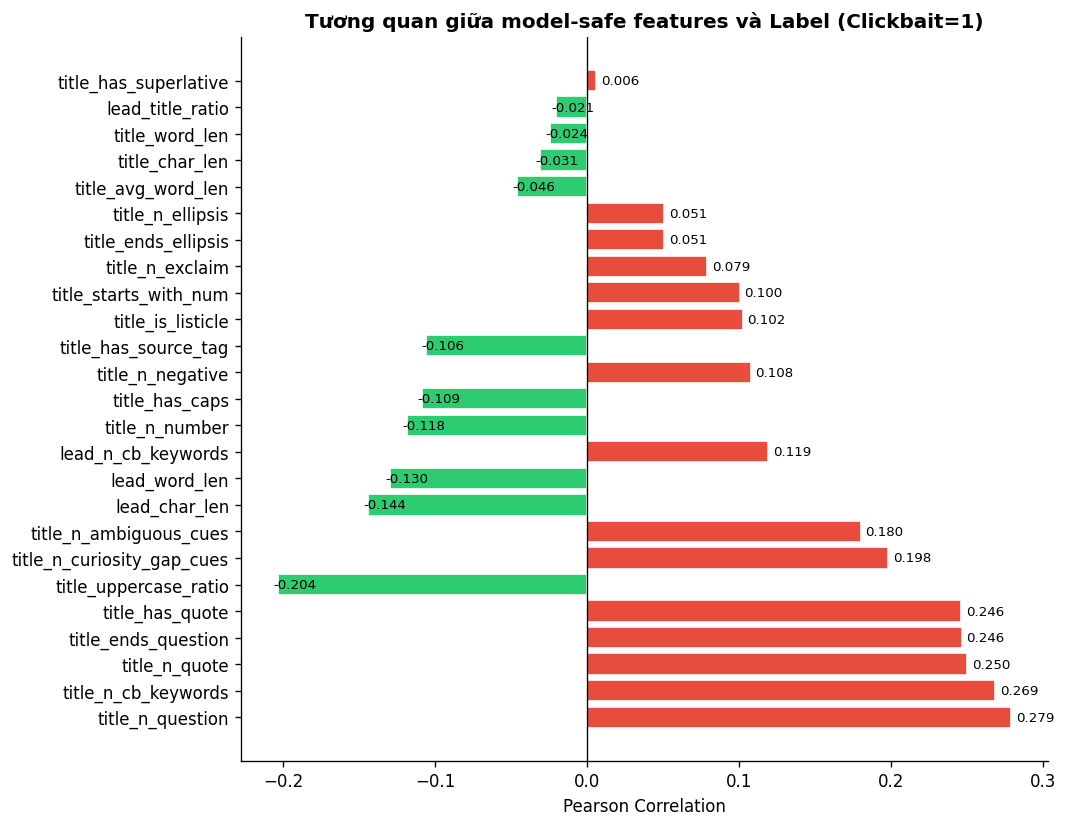

,corr_with_label
title_n_question,0.2792
title_n_cb_keywords,0.2687
title_n_quote,0.2502
title_ends_question,0.2464
title_has_quote,0.2464
title_uppercase_ratio,-0.2037
title_n_curiosity_gap_cues,0.1983
title_n_ambiguous_cues,0.1799
lead_char_len,-0.1444
lead_word_len,-0.1298


In [43]:
label_corr = corr['label'].drop('label').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
colors = [CB_COLOR if v > 0 else NCB_COLOR for v in label_corr.values]
bars = ax.barh(label_corr.index, label_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Tương quan giữa model-safe features và Label (Clickbait=1)', fontweight='bold')
ax.set_xlabel('Pearson Correlation')
for bar, val in zip(bars, label_corr.values):
    offset = 0.003 if val >= 0 else -0.003
    ax.text(bar.get_width() + offset,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

display(label_corr.to_frame('corr_with_label').head(15).round(4))

In [44]:
phase2_checklist = pd.DataFrame([
    {'Output roadmap': 'Kiểm tra schema', 'Status': 'DONE', 'Notebook section': 'Section 3'},
    {'Output roadmap': 'Missing values', 'Status': 'DONE', 'Notebook section': 'Section 4'},
    {'Output roadmap': 'Exact duplicate', 'Status': 'DONE', 'Notebook section': 'Section 5'},
    {'Output roadmap': 'Normalized/near duplicate', 'Status': 'DONE', 'Notebook section': 'Section 5'},
    {'Output roadmap': 'Label distribution', 'Status': 'DONE', 'Notebook section': 'Section 6'},
    {'Output roadmap': 'Source distribution và cb_rate', 'Status': 'DONE', 'Notebook section': 'Section 7'},
    {'Output roadmap': 'Category distribution và cb_rate', 'Status': 'DONE', 'Notebook section': 'Section 8'},
    {'Output roadmap': 'Temporal distribution', 'Status': 'DONE', 'Notebook section': 'Section 9'},
    {'Output roadmap': 'Title length và surface cues', 'Status': 'DONE', 'Notebook section': 'Section 10-11'},
    {'Output roadmap': 'Lead paragraph analysis', 'Status': 'DONE', 'Notebook section': 'Section 12'},
    {'Output roadmap': 'Lexical features cho explainability', 'Status': 'DONE', 'Notebook section': 'Section 13'},
    {'Output roadmap': 'Danh sách rủi ro dataset', 'Status': 'DONE', 'Notebook section': 'Final summary'},
])

display(phase2_checklist)

n_cb = int((df['label'] == 1).sum())
n_ncb = int((df['label'] == 0).sum())

try:
    top_positive = results_df[results_df['Diff CB-NCB'] > 0].head(5)['Feature'].tolist()
    top_negative = results_df[results_df['Diff CB-NCB'] < 0].head(5)['Feature'].tolist()
except NameError:
    top_positive, top_negative = [], []

summary_lines = [
    '=' * 78,
    '  TỔNG KẾT EDA - ViClickbait-2025',
    '=' * 78,
    '',
    'QUY MÔ DATASET:',
    f'  Tổng mẫu giữ lại cho headline-only: {len(df):,} headlines',
    f'  Clickbait: {n_cb:,} ({n_cb/len(df)*100:.1f}%)',
    f'  Non-clickbait: {n_ncb:,} ({n_ncb/len(df)*100:.1f}%)',
    f'  Số source: {df["source"].nunique()}',
    f'  Số category: {df["category"].nunique()}',
    f'  Số dòng parse được publish_datetime: {df["publish_dt"].notna().sum():,}/{len(df):,}',
    '',
    'RỦI RO DATASET:',
    '  Class imbalance: mức vừa phải; không nên dùng accuracy làm metric chính.',
    '  Source bias: cần kiểm tra bằng leave-one-source-out và source-only baseline.',
    '  Category bias: cần kiểm tra category-held-out nếu category đủ mẫu.',
    '  Temporal bias: chỉ dùng temporal split nếu phân phối thời gian đủ hợp lý.',
    '  Duplicate leakage: cần loại/nhóm near-duplicate trước khi tạo split chính.',
    '',
    'CUE NGÔN NGỮ CẦN THEO DÕI:',
    f'  Cue tăng khả năng clickbait: {top_positive}',
    f'  Cue nghiêng về non-clickbait hoặc phản tín hiệu: {top_negative}',
    '  Độ dài title không nên được mặc định xem là cue mạnh nếu chênh lệch nhỏ.',
    '',
    'GỢI Ý CHO PHASE 3:',
    '  1. Tạo random stratified split sau khi xử lý duplicate/near-duplicate.',
    '  2. Tạo leave-one-source-out split để kiểm tra domain generalization.',
    '  3. Không dùng source/category/publish_datetime làm feature chính trong benchmark nếu chưa có leakage-control experiment.',
    '  4. Báo cáo Macro-F1, F1-clickbait, Precision/Recall-clickbait và confusion matrix.',
    '=' * 78,
]
print('\n'.join(summary_lines))

,Output roadmap,Status,Notebook section
0,Kiểm tra schema,DONE,Section 3
1,Missing values,DONE,Section 4
2,Exact duplicate,DONE,Section 5
3,Normalized/near duplicate,DONE,Section 5
4,Label distribution,DONE,Section 6
5,Source distribution và cb_rate,DONE,Section 7
6,Category distribution và cb_rate,DONE,Section 8
7,Temporal distribution,DONE,Section 9
8,Title length và surface cues,DONE,Section 10-11
9,Lead paragraph analysis,DONE,Section 12


  TỔNG KẾT EDA - ViClickbait-2025

QUY MÔ DATASET:
  Tổng mẫu giữ lại cho headline-only: 3,414 headlines
  Clickbait: 1,065 (31.2%)
  Non-clickbait: 2,349 (68.8%)
  Số source: 8
  Số category: 13
  Số dòng parse được publish_datetime: 3,383/3,414

RỦI RO DATASET:
  Class imbalance: mức vừa phải; không nên dùng accuracy làm metric chính.
  Source bias: cần kiểm tra bằng leave-one-source-out và source-only baseline.
  Category bias: cần kiểm tra category-held-out nếu category đủ mẫu.
  Temporal bias: chỉ dùng temporal split nếu phân phối thời gian đủ hợp lý.
  Duplicate leakage: cần loại/nhóm near-duplicate trước khi tạo split chính.

CUE NGÔN NGỮ CẦN THEO DÕI:
  Cue tăng khả năng clickbait: ['title_n_question', 'title_has_quote', 'title_n_quote', 'title_n_cb_keywords', 'title_ends_question']
  Cue nghiêng về non-clickbait hoặc phản tín hiệu: ['title_uppercase_ratio', 'lead_char_len', 'lead_word_len', 'title_n_number', 'title_has_caps']
  Độ dài title không nên được mặc định xem là cue m

In [ ]:
export_cols = ['id', 'title', 'lead_paragraph', 'source',
               'category', 'publish_datetime', 'label'] + NEW_FEATS

df[export_cols].to_csv('viclickbait_eda_features.csv',
                        index=False, encoding='utf-8-sig')
print(f'Exported: viclickbait_eda_features.csv')
print(f'Shape: {df[export_cols].shape[0]:,} rows x {df[export_cols].shape[1]} cols')

Exported: viclickbait_eda_features.csv
Shape: 3,377 rows x 31 cols


In [45]:
from pathlib import Path

OUTPUT_DIR = Path('./')

In [46]:
export_cols = [
    'id', 'title', 'lead_paragraph', 'source', 'category',
    'publish_datetime_raw', 'publish_dt', 'label', 'label_str',
] + MODEL_SAFE_FEATS + LEAKAGE_AUDIT_FEATS + TARGET_RATE_DIAGNOSTICS

existing_export_cols = [c for c in export_cols if c in df.columns]
feature_path = OUTPUT_DIR / 'viclickbait_eda_features.csv'
checklist_path = OUTPUT_DIR / 'viclickbait_phase2_checklist.csv'
source_path = OUTPUT_DIR / 'viclickbait_source_summary.csv'
category_path = OUTPUT_DIR / 'viclickbait_category_summary.csv'

# Export phục vụ phase sau. Không export ảnh/thumbnail trong scope hiện tại.
df[existing_export_cols].to_csv(feature_path, index=False, encoding='utf-8-sig')
phase2_checklist.to_csv(checklist_path, index=False, encoding='utf-8-sig')
source_cb.to_csv(source_path, index=False, encoding='utf-8-sig')
cat_cb.to_csv(category_path, index=False, encoding='utf-8-sig')

print(f'Đã export feature file: {feature_path}')
print(f'Shape: {df[existing_export_cols].shape[0]:,} rows x {df[existing_export_cols].shape[1]} cols')
print(f'Đã export checklist: {checklist_path}')
print(f'Đã export source summary: {source_path}')
print(f'Đã export category summary: {category_path}')

Đã export feature file: viclickbait_eda_features.csv
Shape: 3,414 rows x 38 cols
Đã export checklist: viclickbait_phase2_checklist.csv
Đã export source summary: viclickbait_source_summary.csv
Đã export category summary: viclickbait_category_summary.csv
